# Experiment – 9 : Naive Bayes

---

**Name:** Shruti Hore  

**PRN:** 24070126172  

---

**Title:** Implementation of Naive Bayes for Classification

---

**Aim:**
To implement and understand the Naïve Bayes algorithm for classification tasks and
evaluate its performance on a given dataset.

---

**Objective:**

•	The classification mechanism of Naive Bayes.

•	The mathematical formulation and working principle of Naive Bayes.

•	Evaluating the model's performance using relevant metrics

•	Comparing Naive Bayes with other classification models


---

**Problem statement**

Use the given dataset(s) to demonstrate the application of the Naive Bayes algorithm for classification. The task is to classify the data points into different classes based on features and understand the feature independence assumption.

---

**Description**

Naive Bayes is a supervised learning algorithm based on Bayes’ Theorem. It is primarily used for classification tasks. It is called "Naive" because it assumes that the presence of a particular feature in a class is unrelated to the presence of any other feature (Feature Independence).

---

**Mathematical Formulation**

The algorithm calculates the probability of a class given a set of features using the following formula:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Where:

$P(A|B)$: Posterior probability (Probability of class $A$ given predictor $B$).

$P(A)$: Prior probability of class.

$P(B|A)$: Likelihood (Probability of predictor given class).

$P(B)$: Prior probability of predictor.

---

**Assumptions**

- Feature Independence: All features are independent of each other.

- Equal Contribution: Each feature has an equal effect on the outcome.

---


**Types of Naive Bayes Models**
- Gaussian NB: Used when features follow a normal distribution.

- Multinomial NB: Used for discrete counts (e.g., text classification/word counts).

- Bernoulli NB: Used when features are binary (0s and 1s).

---

**Importance and Applications**
- Importance: It is highly scalable, fast, and performs well even with small amounts of training data.

- Applications: Spam filtering, sentiment analysis, medical diagnosis, and real-time predictions.

---

# 1. Social Network Ads
- Focus: Predicts purchase behavior using Age and Salary.
- Model: Gaussian Naive Bayes was used since features are continuous.
- Result: High performance with 91.25% Accuracy and 0.9131 F1 Score.
- Step: Requires feature scaling for optimal results .

In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                             classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve, auc)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('(9) Social_Network_Ads.csv')
data.head().T

,0,1,2,3,4
User ID,15624510,15810944,15668575,15603246,15804002
Gender,Male,Male,Female,Female,Male
Age,19,35,26,27,19
EstimatedSalary,19000,20000,43000,57000,76000
Purchased,0,0,0,0,0


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


In [4]:
print(data.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [5]:
print(data.describe())

            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [7]:
# Select Features and Target
X = data.iloc[:, [2, 3]].values  # Age and Salary
y = data.iloc[:, -1].values      # Purchased

In [8]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{pd.Series(y).value_counts()}")

Features shape: (400, 2)
Target shape: (400,)
Target distribution:
0    257
1    143
Name: count, dtype: int64


In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state=0)
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Train set size: 320
Test set size: 80


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
print(f"Scaled training data - Mean: {X_train_scaled.mean(axis=0)}")
print(f"Scaled training data - Std: {X_train_scaled.std(axis=0)}")

Scaled training data - Mean: [1.17961196e-17 2.84494650e-17]
Scaled training data - Std: [1. 1.]


In [12]:
# Model Training
model_gnb = GaussianNB()
model_gnb.fit(X_train_scaled, y_train)

GaussianNB()

In [13]:
# Make Predictions
y_pred_gnb = model_gnb.predict(X_test_scaled)
y_pred_proba_gnb = model_gnb.predict_proba(X_test_scaled)

In [14]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
acc_gnb = accuracy_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb, average="weighted")
roc_auc_gnb = roc_auc_score(y_test, y_pred_proba_gnb[:, 1])

print(f"Confusion Matrix:\n{cm_gnb}")
print(f"\nAccuracy: {acc_gnb:.4f}")
print(f"F1 Score (weighted): {f1_gnb:.4f}")
print(f"ROC-AUC Score: {roc_auc_gnb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=['Not Purchased', 'Purchased']))

Confusion Matrix:
[[55  3]
 [ 4 18]]

Accuracy: 0.9125
F1 Score (weighted): 0.9119
ROC-AUC Score: 0.9843

Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.93      0.95      0.94        58
    Purchased       0.86      0.82      0.84        22

     accuracy                           0.91        80
    macro avg       0.89      0.88      0.89        80
 weighted avg       0.91      0.91      0.91        80



Text(0.5, 80.7222222222222, 'Predicted Label')

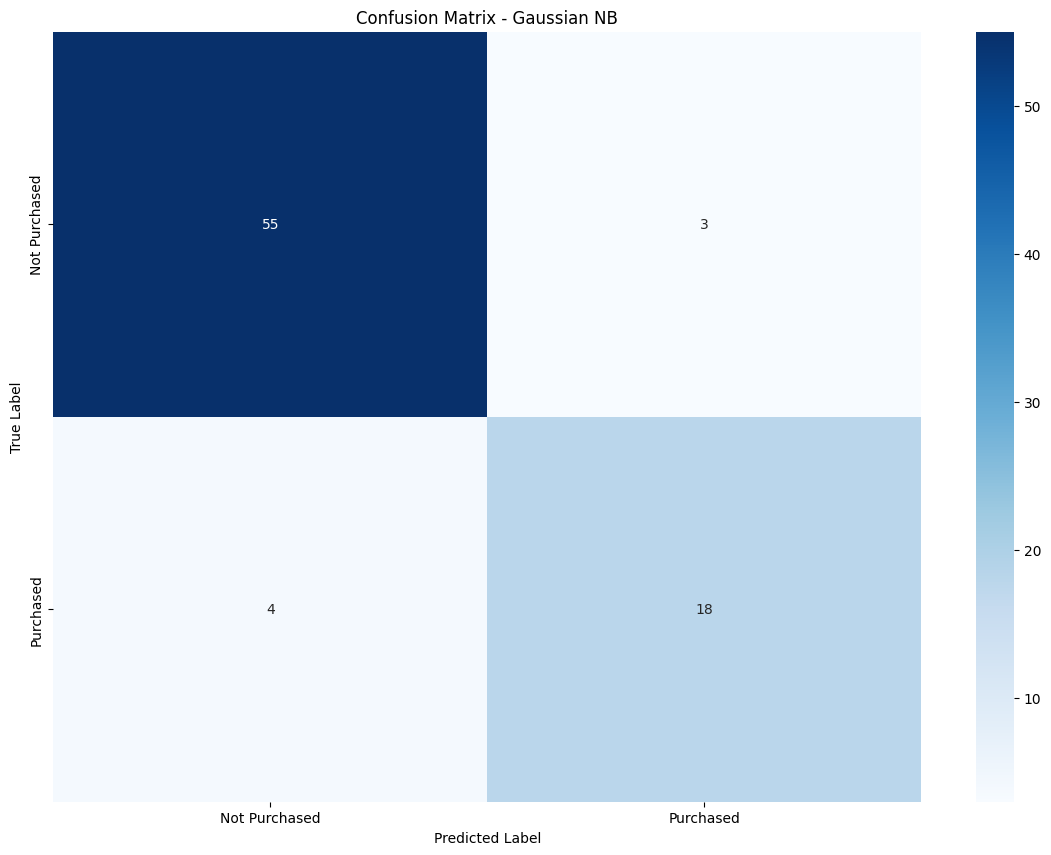

In [15]:
# Visualization of Results

fig, axes = plt.subplots(figsize=(14, 10))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
axes.set_title('Confusion Matrix - Gaussian NB')
axes.set_ylabel('True Label')
axes.set_xlabel('Predicted Label')

# 2. Adult Dataset
- Focus: Large-scale data (32,561 rows) to predict if income exceeds $50k.
- Complexity: Contains 9 categorical variables like workclass and education.
- Data Issue: Identified missing values labeled as "?" in the workclass column.
- Status: Implementation is currently at the EDA phase; encoding is required next

In [ ]:
adt = pd.read_csv('(9) adult.csv',
                   header=None, sep=',\s')

col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
             'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
             'hours_per_week', 'native_country', 'income']
adt.columns = col_names


In [17]:
print(adt.head())

   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [18]:
print(f"Dataset Shape: {adt.shape}")

Dataset Shape: (32561, 15)


In [19]:
print(adt.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [20]:
print(adt.isnull().sum())


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [21]:
print(adt.describe())

                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [22]:
print(f"\nCategorical Features:")
cat_cols = [col for col in adt.columns if adt[col].dtype == 'O']
print(f"Found {len(cat_cols)} categorical variables:")
print(cat_cols)


Categorical Features:
Found 9 categorical variables:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [23]:
print(f"\nIncome Distribution:")
print(adt['income'].value_counts())

print(f"\nTarget Variable Percentage:")
print(adt['income'].value_counts(normalize=True) * 100)


Income Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Target Variable Percentage:
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


In [24]:
adt.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [25]:
for col in cat_cols:
    missing_count = (adt[col] == '?').sum()
    if missing_count > 0:
        print(f"{col}: {missing_count} missing values ({missing_count/len(adt)*100:.2f}%)")

print(f"\nWorkclass value distribution:")
print(adt['workclass'].value_counts())

workclass: 1836 missing values (5.64%)
occupation: 1843 missing values (5.66%)
native_country: 583 missing values (1.79%)

Workclass value distribution:
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


Handling missing values (?)

1. Keep '?' as 'Unknown'


In [26]:
adt_keep = adt.copy()
adt_keep.replace('?', 'Unknown', inplace=True)

X_keep = pd.get_dummies(adt_keep.drop('income', axis=1), drop_first=False)
y_keep = adt_keep['income']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_keep, y_keep, test_size=0.3, random_state=42)

In [27]:
# Scale features
scaler_1 = StandardScaler()
X_train_1_scaled = scaler_1.fit_transform(X_train_1)
X_test_1_scaled = scaler_1.transform(X_test_1)

# Train model
model_1 = GaussianNB()
model_1.fit(X_train_1_scaled, y_train_1)
y_pred_1 = model_1.predict(X_test_1_scaled)

print(f"Accuracy (Keep as Unknown): {accuracy_score(y_test_1, y_pred_1):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test_1, y_pred_1)}")
print(f"Classification Report:")
print(classification_report(y_test_1, y_pred_1, target_names=['<=50K', '>50K']))

Accuracy (Keep as Unknown): 0.4123
Confusion Matrix:
[[1763 5692]
 [  49 2265]]
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.97      0.24      0.38      7455
        >50K       0.28      0.98      0.44      2314

    accuracy                           0.41      9769
   macro avg       0.63      0.61      0.41      9769
weighted avg       0.81      0.41      0.39      9769



2. Drop rows with missing values

In [28]:
adt_drop = adt.copy()
adt_drop.replace('?', np.nan, inplace=True)
initial_rows = len(adt_drop)
adt_drop.dropna(inplace=True)
rows_removed = initial_rows - len(adt_drop)
print(f"Rows removed: {rows_removed} ({rows_removed/initial_rows*100:.2f}%)")

X_drop = pd.get_dummies(adt_drop.drop('income', axis=1), drop_first=False)
y_drop = adt_drop['income']

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_drop, y_drop, test_size=0.3, random_state=42)

Rows removed: 2399 (7.37%)


In [29]:
# Scale features
scaler_2 = StandardScaler()
X_train_2_scaled = scaler_2.fit_transform(X_train_2)
X_test_2_scaled = scaler_2.transform(X_test_2)

# Train model
model_2 = GaussianNB()
model_2.fit(X_train_2_scaled, y_train_2)
y_pred_2 = model_2.predict(X_test_2_scaled)

print(f"Accuracy (Drop Missing): {accuracy_score(y_test_2, y_pred_2):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test_2, y_pred_2)}")
print(f"Classification Report:")
print(classification_report(y_test_2, y_pred_2, target_names=['<=50K', '>50K']))

Accuracy (Drop Missing): 0.4292
Confusion Matrix:
[[1679 5088]
 [  77 2205]]
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.96      0.25      0.39      6767
        >50K       0.30      0.97      0.46      2282

    accuracy                           0.43      9049
   macro avg       0.63      0.61      0.43      9049
weighted avg       0.79      0.43      0.41      9049



3. Impute with mode

In [30]:
adt_imp = adt.copy()
for col in ['workclass', 'occupation', 'native_country']:
    mode_val = adt_imp[col].mode()[0]
    adt_imp[col] = adt_imp[col].replace('?', mode_val)

X_imp = pd.get_dummies(adt_imp.drop('income', axis=1), drop_first=False)
y_imp = adt_imp['income']

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_imp, y_imp, test_size=0.3, random_state=42)

In [31]:
# Scale features
scaler_3 = StandardScaler()
X_train_3_scaled = scaler_3.fit_transform(X_train_3)
X_test_3_scaled = scaler_3.transform(X_test_3)

# Train model
model_3 = GaussianNB()
model_3.fit(X_train_3_scaled, y_train_3)
y_pred_3 = model_3.predict(X_test_3_scaled)

print(f"Accuracy (Mode Imputation): {accuracy_score(y_test_3, y_pred_3):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test_3, y_pred_3)}")
print(f"Classification Report:")
print(classification_report(y_test_3, y_pred_3, target_names=['<=50K', '>50K']))

Accuracy (Mode Imputation): 0.3990
Confusion Matrix:
[[1631 5824]
 [  47 2267]]
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.97      0.22      0.36      7455
        >50K       0.28      0.98      0.44      2314

    accuracy                           0.40      9769
   macro avg       0.63      0.60      0.40      9769
weighted avg       0.81      0.40      0.38      9769



## Conclusion
The project demonstrates that Naive Bayes is a fast, scalable classifier for both simple and complex datasets. While the Social Network Ads model was highly successful, the Adult Dataset highlights the necessity of rigorous data cleaning (handling "?" values) and categorical encoding in real-world pipelines.


Feature Independence Impact
Although Naive Bayes "naively" assumes features are independent—which is rarely true in census data (e.g., education vs. occupation)—the algorithm remains remarkably robust and effective for classification tasks.